# Getting started with SHAD

This notebook walks through the **SHAD** benchmark (Scality High-dimensional Anomaly Detection):

1. browsing the catalog of the 215 series,
2. loading one series with its **top-level** and **per-dimension** labels,
3. reading the **XML annotation** (anomaly events, affected components, metric descriptions),
4. plotting a series,
5. building the train / test split used in the paper and running a tiny baseline.

> Run it from the repository root (or a sub-folder), after `pip install -e .`
> — or set the `SHAD_ROOT` environment variable to your local copy of the repository.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shad
from shad import SHAD

ds = SHAD()   # auto-detects the repository (or SHAD(root="path/to/shad"))
ds

SHAD(root='/home/claude/shad-upstream', series=215, nominal=83, anomalous=132)

## 1. The catalog
One row per series. `group` is the experiment family (folder of `Dataset/`); `type`, `category` and `criticality` come from the XML annotation.

In [2]:
ds.summary()

,group,type,category,criticality,series
0,Nominal,None,None,None,83
1,Single Disk,Disk,Single,Low,10
2,Simultaneous Disk,Disk,Simultaneous,Medium,17
3,Asynchronous Disk,Disk,Asynchronous,High,11
4,Single Server,Server,Single,Low,11
5,Asynchronous Server,Server,Asynchronous,Medium,11
6,Server Degradation,Server,Degradation,High,26
7,Single SNode,SNode,Single,Low,16
8,Simultaneous SNode,SNode,Simultaneous,Medium,14
9,Asynchronous SNode,SNode,Asynchronous,High,16


In [3]:
cat = ds.catalog
cat[["id", "group", "type", "category", "criticality", "n_events", "broken_telemetry", "explanation"]].head(8)

,id,group,type,category,criticality,n_events,broken_telemetry,explanation
0,1773251393,Nominal,None,None,None,0,False,Nominal Workload
1,1773251399,Nominal,None,None,None,0,False,Nominal Workload
2,1773343560,Nominal,None,None,None,0,False,Nominal Workload
3,1773343565,Nominal,None,None,None,0,False,Nominal Workload
4,1773343568,Nominal,None,None,None,0,False,Nominal Workload
5,1773521107,Nominal,None,None,None,0,False,Nominal Workload
6,1773521116,Nominal,None,None,None,0,False,Nominal Workload
7,1773521128,Nominal,None,None,None,0,False,Nominal Workload


In [4]:
# ids can be selected with metadata filters
high_disk = ds.filter(type="Disk", criticality="High")
print(len(high_disk), "high-criticality disk series:", high_disk[:5], "...")

11 high-criticality disk series: ['1773429559', '1773429588', '1773429647', '1773429670', '1773767292'] ...


## 2. Loading one series
`ds.load(id)` returns a `Series` object with

* `data` — `(n, 171)` DataFrame of telemetry indexed by UTC timestamps (1-minute sampling)
* `labels` — `(n, 171)` per-dimension binary labels (same columns)
* `label` — `(n,)` top-level label (1 while an anomaly is ongoing)
* `annotation` — the parsed XML file

Numpy views are available as `X`, `Y` and `y`.

In [5]:
s = ds.load("1774026259")   # a server degradation experiment
print(s)
print(s.explanation)
s.data.iloc[:5, :6]

Series(id=1774026259, group='Server Degradation', shape=(1000, 171), anomaly_ratio=0.084, anomalous_dimensions=47)
ran on quarry5 starting at 2026-03-20 17:04, with a gradual node failure on store 1 at time 6h for 2h, where delay and loss jump to 100ms and 5% at 25% of the anomaly duration, 300ms and 10% at 50%, and 800ms and 20% at 75%.


,cpu_usage_ratio,cpu_load_ratio,memory_usage_ratio,network_in_bytes,network_out_bytes,objects_count
timestamp,,,,,,
2026-03-20 17:15:00.054000+00:00,0.634887,0.927500,0.702731,2.232205e+07,2.620246e+07,78164.0
2026-03-20 17:16:00.052000+00:00,0.646601,0.967500,0.702295,2.359699e+07,2.773236e+07,79634.0
2026-03-20 17:17:00.052000+00:00,0.644240,1.000625,0.706119,2.312698e+07,2.718022e+07,81259.0
2026-03-20 17:18:00.052000+00:00,0.657255,1.029688,0.705511,2.503879e+07,2.938759e+07,82502.0
2026-03-20 17:19:00.053000+00:00,0.658761,1.025000,0.704202,2.490218e+07,2.905527e+07,83301.0


In [6]:
print("X:", s.X.shape, " Y:", s.Y.shape, " y:", s.y.shape)
print("anomalous intervals (row indices, end exclusive):", s.segments())
print("fraction of anomalous timestamps: %.3f" % s.y.mean())
print("number of labelled dimensions:", len(s.anomalous_dimensions))

X: (1000, 171)  Y: (1000, 171)  y: (1000,)
anomalous intervals (row indices, end exclusive): [(346, 430)]
fraction of anomalous timestamps: 0.084
number of labelled dimensions: 47


The top-level label is exactly the logical OR of the 171 per-dimension labels:

In [7]:
assert np.array_equal(s.y, s.Y.max(axis=1))

### Missing values
The telemetry contains some missing values (monitoring gaps). They are kept as `NaN` by default; use `fill="ffill"`, `"interpolate"` or `"zero"` to impute them at load time.

In [8]:
print("missing values per dimension (top 5):")
print(s.data.isna().sum().sort_values(ascending=False).head())
s_filled = ds.load("1774026259", fill="ffill")
print("after ffill:", int(s_filled.data.isna().sum().sum()), "missing values")

missing values per dimension (top 5):
s3_errors_5xx                 37
s3_request_get_operations     35
s3_request_put_operations     35
s3_request_post_operations    35
s3_request_head_operations    35
dtype: int64
after ffill: 0 missing values


## 3. The XML annotation
Each series comes with `Annotations/<id>.xml`, describing the anomaly (presence, category, type, criticality, textual explanation) and every dimension (description, anomaly events with onset, duration, targeted store/disk, degradation level and the list of dimensions affected by the same event).

In [9]:
ann = s.annotation
ann.summary()

{'id': '1774026259',
 'anomaly_presence': True,
 'category': 'Degradation',
 'type': 'Server',
 'criticality': 'High',
 'explanation': 'ran on quarry5 starting at 2026-03-20 17:04, with a gradual node failure on store 1 at time 6h for 2h, where delay and loss jump to 100ms and 5% at 25% of the anomaly duration, 300ms and 10% at 50%, and 800ms and 20% at 75%.',
 'n_events': 1,
 'n_anomalous_dimensions': 47}

In [10]:
for e in ann.events:
    print(e.component, "| onset:", e.offset_minutes, "min | duration:", e.duration_minutes,
          "min | degradation:", e.degradation, "|", len(e.related_dimensions), "related dimensions")

store1 | onset: 360 min | duration: 120 min | degradation: 800ms | 47 related dimensions


In [11]:
dim = "store1-latency_sent_milliseconds"
print(dim, "->", ann.descriptions[dim])
print("related dimensions:", ann.related_dimensions(dim)[:6], "...")

store1-latency_sent_milliseconds -> (ms) Average round-trip time for RING operations that store1 sends.
related dimensions: ['store1-balance_balanced_tasks', 'store1-balance_scanned_tasks', 'store1-cpu_load_ratio', 'store1-cpu_usage_ratio', 'store1-errors_received', 'store1-errors_sent'] ...


### Metric dictionary
`shad.metric_info` and `shad.metrics_table()` document the 171 dimensions (4 levels: platform, S3, server, device).

In [12]:
mt = shad.metrics_table()
print(mt.level.value_counts().to_dict())
mt.sample(6, random_state=0)[["name", "level", "store", "device", "unit", "description"]]

{'device': 84, 'server': 57, 'platform': 17, 's3': 13}


,name,level,store,device,unit,description
54,store1-memory_usage_ratio,server,store1,NaN,ratio,Fraction of total used memory.
145,store3-g2disk01-disk_usage_ratio,device,store3,g2disk01,ratio,Disk space utilisation. Device: NVMe data disk...
63,store1-operations_received,server,store1,NaN,ops/s,Rate of internal RING operations received from...
55,store2-memory_usage_ratio,server,store2,NaN,ratio,Fraction of total used memory.
125,store3-g2disk02-disk_read_bytes,device,store3,g2disk02,bytes/s,Disk read throughput. Device: NVMe data disk (...
100,store2-ssd02-disk_io_time_seconds,device,store2,ssd02,s/s,Fraction of time spent on I/O. Close to 1.0 me...


In [13]:
# select dimensions by level / store / device / metric
shad.select(level="device", store="store1", device="g2disk01")

['store1-g2disk01-disk_io_time_seconds',
 'store1-g2disk01-disk_read_bytes',
 'store1-g2disk01-disk_usage_ratio',
 'store1-g2disk01-disk_write_bytes']

## 4. Plotting
`Series.plot()` draws the labelled dimensions (light red: top-level label, dark red: per-dimension label).

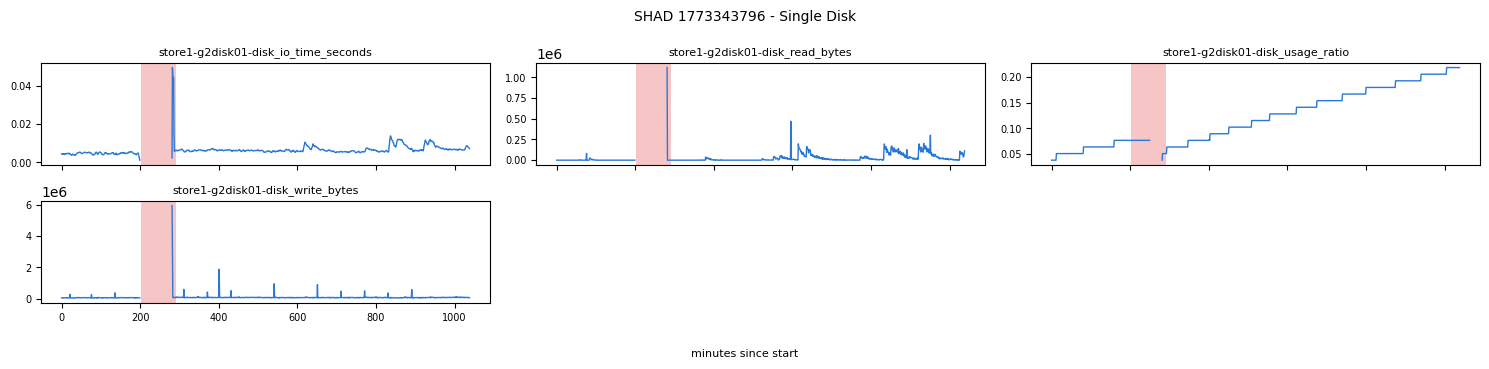

In [14]:
fig = ds.load("1773343796").plot()   # single disk failure: 4 labelled dimensions

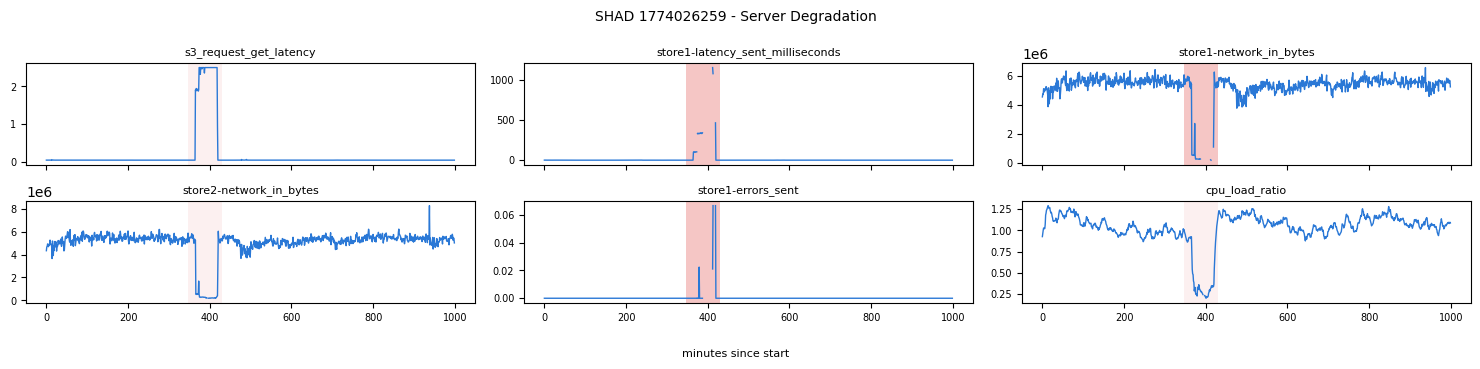

In [15]:
fig = s.plot(dimensions=["s3_request_get_latency", "store1-latency_sent_milliseconds",
                         "store1-network_in_bytes", "store2-network_in_bytes",
                         "store1-errors_sent", "cpu_load_ratio"])

## 5. Benchmark split and a tiny baseline
In the paper, semi-supervised detectors are trained on the **83 nominal series** and all methods are evaluated on the **132 anomalous series** (VUS-PR, via [TSB-AD](https://github.com/TheDatumOrg/TSB-AD)).

Below, a toy detector: robust z-scores w.r.t. nominal statistics.

In [16]:
train_ids, test_ids = ds.split()
X_train = np.concatenate([ds.load(i, fill="ffill").X for i in train_ids])
med = np.nanmedian(X_train, axis=0)
mad = np.nanmedian(np.abs(X_train - med), axis=0) * 1.4826 + 1e-9
print("training timestamps:", X_train.shape)

training timestamps: (86525, 171)


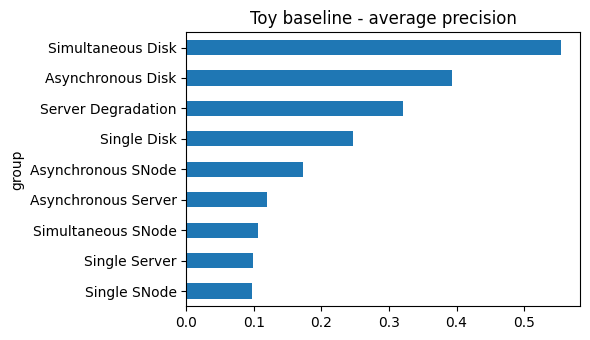

In [17]:
def average_precision(y, score):
    order = np.argsort(-score); y = y[order]
    precision = np.cumsum(y) / np.arange(1, len(y) + 1)
    return (precision * y).sum() / max(y.sum(), 1)

rows = []
for sid in test_ids:
    t = ds.load(sid, fill="ffill")
    z = np.clip(np.abs((t.X - med) / mad), 0, 50)
    rows.append({"id": sid, "group": t.group, "AP": average_precision(t.y, z.mean(axis=1))})
res = pd.DataFrame(rows)
res.groupby("group").AP.mean().sort_values().plot.barh(figsize=(6, 3.5), title="Toy baseline - average precision")
plt.tight_layout()

## Next steps

* Explore every series interactively in the **[SHAD explorer](https://scality.github.io/shad/explorer.html)**.
* Benchmark detectors with **[TSB-AD](https://github.com/TheDatumOrg/TSB-AD)** (VUS-PR).
* Reproduce the LLM interpretability experiment with the scripts in `Scripts/` (see the README).